# Exploratory Data Analysis for Text and Vote Label
This notebook performs EDA on the `fetched_data.json` dataset, focusing on text and vote label analysis. Tasks include:
- Data overview and label distribution
- Text length analysis
- Word frequency and word cloud per label
- Keyword and URL analysis
- Sentiment analysis (optional, if supported)

In [2]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

In [3]:
# Load the JSON data
with open('d:/laragon/www/Skripsi/Preprocessing/fetched_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
if isinstance(data, dict):
    for v in data.values():
        if isinstance(v, list):
            data = v
            break
df = pd.DataFrame(data)
print('Number of records:', len(df))
df.head()

Number of records: 10055


,text,votes
0,"Harinya sudah datang, mari meramaikan hari ini...",False
1,mantap linkBONBON777 berani kasi kemenangan be...,True
2,WD lagi coy di MAHASLOT royal bro 20jt dikasih...,True
3,Gacor parah ey mantap #MAHASLOT,True
4,🤑Udah Siap Buat Klaim 𝗙𝗥𝗘𝗘𝗕𝗘𝗧 𝗣𝗘𝗣𝗘𝟴𝟴𝟵 ?\n\nCar...,True


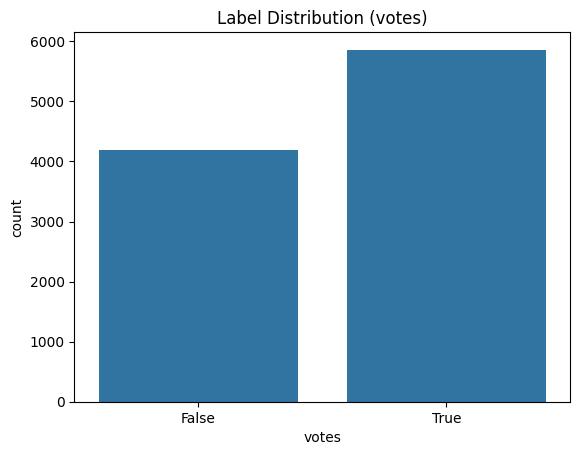

votes
True     5861
False    4194
Name: count, dtype: int64

In [3]:
# Label distribution
sns.countplot(x='votes', data=df)
plt.title('Label Distribution (votes)')
plt.show()
df['votes'].value_counts()

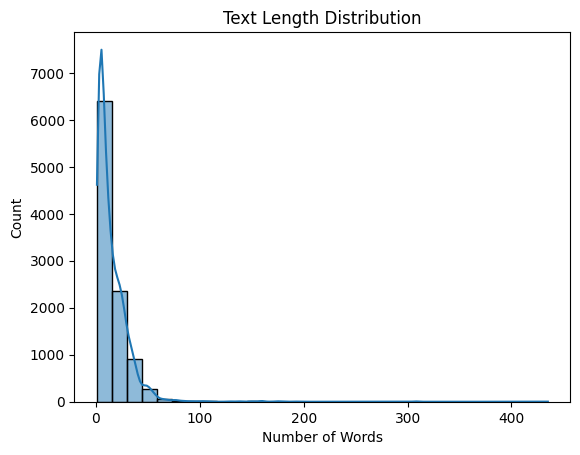

,count,mean,std,min,25%,50%,75%,max
votes,,,,,,,,
False,4194.0,7.755842,13.789809,1.0,3.0,5.0,8.0,435.0
True,5861.0,20.641188,16.942809,1.0,10.0,18.0,27.0,308.0


In [4]:
# Text length analysis
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Number of Words')
plt.show()
df.groupby('votes')['text_length'].describe()

In [11]:
# Word frequency analysis for each label (table format, remove stopwords and punctuation)
from collections import Counter
from wordcloud import STOPWORDS
import pandas as pd
import string
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['yang', 'dan', 'di', 'ke', 'untuk', 'dengan', 'atau', 'ini', 'itu', 'nya', 'aja'])
def get_top_words_table(texts, n=50):
    # Remove punctuation and lowercase
    def clean_text(text):
        return str(text).lower().translate(str.maketrans('', '', string.punctuation))
    cleaned_texts = [clean_text(t) for t in texts]
    words = ' '.join(cleaned_texts).split()
    words = [w for w in words if w not in custom_stopwords]
    counter = Counter(words)
    df_freq = pd.DataFrame(counter.items(), columns=['Word', 'Frequency'])
    df_freq = df_freq.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
    return df_freq.head(n)
print('Top words for votes=True:')
display(get_top_words_table(df[df['votes']==True]['text']))
# print('Top words for votes=False:')
# display(get_top_words_table(df[df['votes']==False]['text']))

Top words for votes=True:


,Word,Frequency
0,main,2028
1,s1tus,1370
2,banget,1270
3,situs,1131
4,nih,865
5,baru,816
6,kasih,745
7,𝐏𝐔𝐓𝐑𝐈𝐒𝐏𝐈𝐍,738
8,udah,727
9,bisa,701


mantap linkbonbon777 berani kasi kemenangan besar untuk orang baru wd lagi coy di mahaslot royal bro 20jt dikasih nya hahah mantap gacor parah ey mantap mahaslot 🤑udah siap buat klaim 𝗙𝗥𝗘𝗘𝗕𝗘𝗧 𝗣𝗘𝗣𝗘𝟴𝟴𝟵 cara ✨gruptelegram👇👇 httpstmepepe889groupfreebet ✨link daftar👇👇 httpsmezinkparty • login klik promo saya bonus masukkan kode apply 𝐒𝐇𝐈𝐎𝐊𝐀𝐌𝐁𝐈𝐍𝐆𝟓 link paling ajaib kasih scatter tanpa hitungan modal besar langsung di jp ku kira isi nya ga sesuai ekspetasi ternyatagilak bener bray cobain aja kalau caya tqbonbon777 🔥 special new provider game panasnya ggsoft panen138 🔥hanya dengan modal 50ribu bisa wede 4juta 💥nikmati cuan main di panen138💸 link daftar httpsheylink memaricuanbersamapanen138 info aja lur selagi masih bagusnya baru dikash jepe besar gacor linksakau007 💱list apk slot wd tampa dp ❓depo 50k 20k bonus new member 1superspin➡️ link apk⬇️ httpswwwsuperspincloudchnbnrfc3vwzxjzcglux2jnidnzk5njgyntex 2rr777➡️ httpswwwrrvip8comchncni3nzdfawq3x250bgexmaidmtk4mji3njuy 38638slots➡️ httpswww86

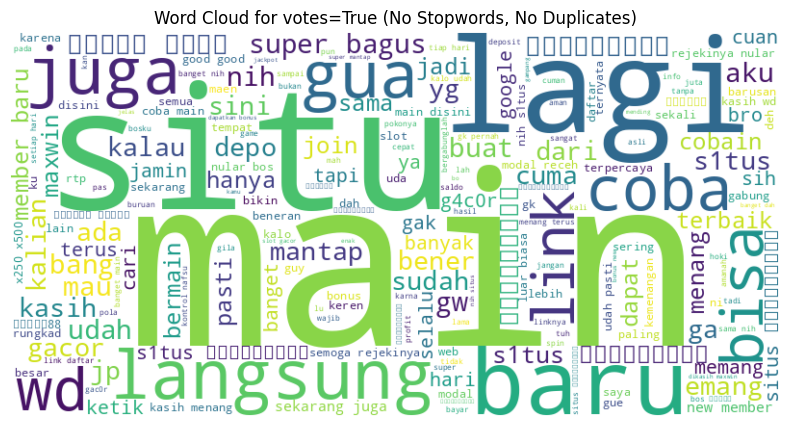

In [ ]:
# Word cloud for each label (excluding stopwords and removing duplicates)
from wordcloud import STOPWORDS
custom_stopwords = set(STOPWORDS)
# Optionally add more stopwords relevant to your context
custom_stopwords.update(['yang', 'dan', 'di', 'ke', 'untuk', 'dengan', 'atau', 'ini', 'itu', 'nya', 'aja'])
import string
def preprocess_text(text):
    # Lowercase, remove punctuation, split, remove duplicates, join back
    words = str(text).lower().translate(str.maketrans('', '', string.punctuation)).split()
    unique_words = list(dict.fromkeys(words))
    return ' '.join(unique_words)
for label in [True]:
    texts = df[df['votes']==label]['text'].dropna().astype(str).apply(preprocess_text)
    all_text = ' '.join(texts)
    # print(all_text)
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stopwords).generate(all_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for votes={label} (No Stopwords, No Duplicates)')
    plt.show()

Texts containing 'bonus': 479
Texts containing 'petir': 110
Texts containing 'link': 885
Texts containing 'daftar': 363
Texts containing URLs: 1081


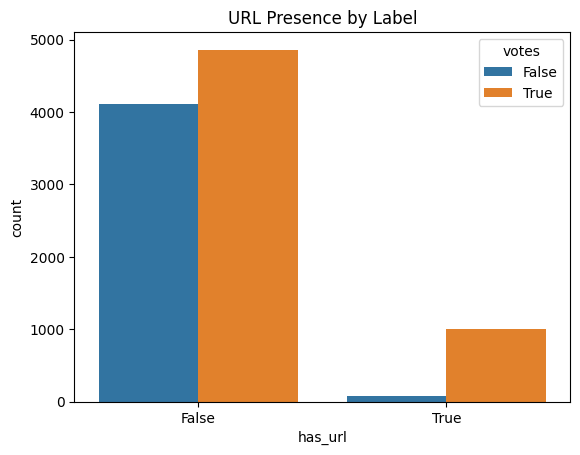

In [5]:
# Keyword and URL analysis
keywords = ['bonus', 'petir', 'link', 'daftar']
for kw in keywords:
    df[f'has_{kw}'] = df['text'].str.contains(kw, case=False, na=False)
    print(f"Texts containing '{kw}':", df[f'has_{kw}'].sum())
# URL presence
df['has_url'] = df['text'].str.contains(r'http[s]?://', na=False)
print('Texts containing URLs:', df['has_url'].sum())
sns.countplot(x='has_url', hue='votes', data=df)
plt.title('URL Presence by Label')
plt.show()

In [ ]:
# (Optional) Sentiment analysis if you have a sentiment library installed
# Example using textblob (pip install textblob)
try:
    from textblob import TextBlob
    df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    sns.histplot(df['sentiment'], bins=30, kde=True)
    plt.title('Sentiment Distribution')
    plt.show()
    print(df.groupby('votes')['sentiment'].describe())
except ImportError:
    print('TextBlob not installed. Sentiment analysis skipped.')

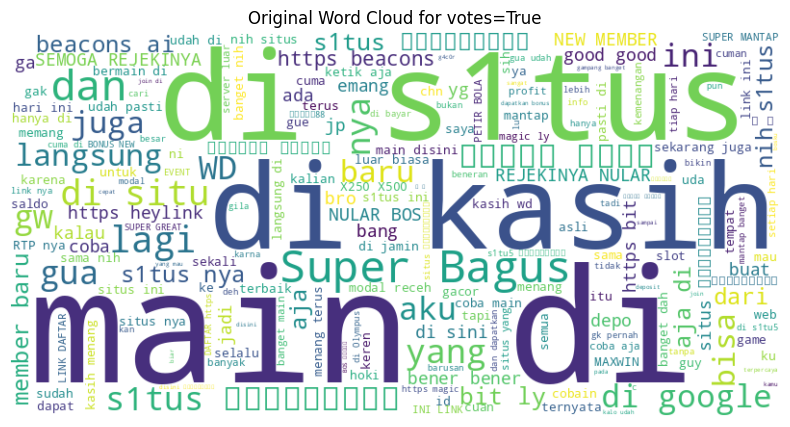

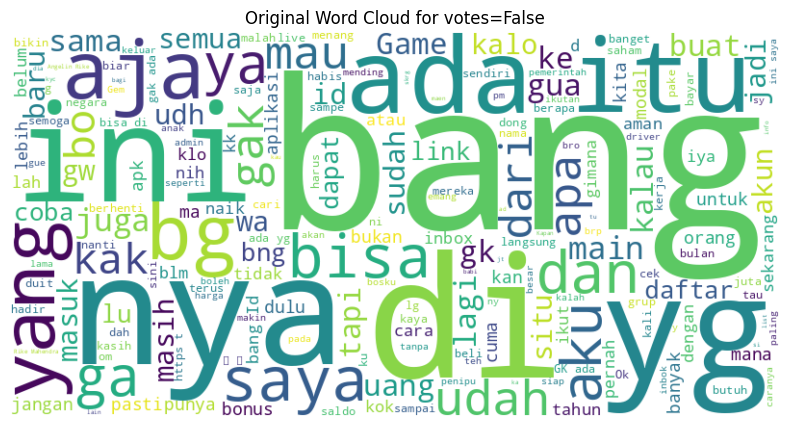

In [13]:
# Original word cloud for each label (no stopwords, no duplicate removal, no punctuation cleaning)
for label in [True, False]:
    texts = ' '.join(df[df['votes']==label]['text'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texts)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Original Word Cloud for votes={label}')
    plt.show()